# 🏥 Diabetes-Risiko-Vorhersage – ML Pipeline
**Portfolio-Projekt | Machine Learning + Healthcare**

---
**Ziel:** Echtzeit-Patientendaten simulieren, ein ML-Modell trainieren und das Diabetesrisiko vorhersagen.

**Pipeline:**
1. Echtzeit-Datensimulator (Faker + statistische Verteilungen)
2. Explorative Datenanalyse (EDA)
3. Feature Engineering
4. Modelltraining & Vergleich (LR, RF, XGBoost)
5. Evaluation (AUC-ROC, Recall, Confusion Matrix)
6. Modell-Interpretierbarkeit mit SHAP
7. Modell exportieren → bereit für Power BI


## 0. Bibliotheken installieren & importieren

In [16]:
# Installation (nur beim ersten Mal nötig)
%pip install faker scikit-learn xgboost shap matplotlib seaborn joblib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap
import joblib

# Datensimulator
from faker import Faker
import random

fake = Faker('de_DE')
np.random.seed(42)
random.seed(42)

print('✅ Alle Bibliotheken geladen')

Note: you may need to restart the kernel to use updated packages.
✅ Alle Bibliotheken geladen



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Echtzeit-Datensimulator
Simuliert realistische Patientendaten basierend auf epidemiologischen Studien (CDC, WHO).

In [17]:
def generate_patient(n=1):
    """
    Generiert n synthetische Patientendatensätze.
    Verteilungen basieren auf CDC NHANES Studie 2017-2020.
    """
    records = []
    for _ in range(n):
        # Demographische Daten
        age = int(np.random.normal(52, 15))
        age = np.clip(age, 21, 90)
        sex = random.choice([0, 1])  # 0=weiblich, 1=männlich

        # Klinische Werte (leicht korreliert für Realismus)
        bmi = np.random.normal(28.5, 6.5)
        bmi = round(np.clip(bmi, 15, 55), 1)

        # Glukose: höher bei hohem BMI
        base_glucose = 90 + (bmi - 25) * 1.8 + age * 0.3
        glucose = int(np.random.normal(base_glucose, 30))
        glucose = np.clip(glucose, 60, 300)

        # Blutdruck
        blood_pressure = int(np.random.normal(72 + age * 0.1, 12))
        blood_pressure = np.clip(blood_pressure, 40, 130)

        # Insulin (stark variabel)
        insulin = int(np.random.exponential(80))
        insulin = np.clip(insulin, 0, 600)

        # Hautdicke (Triceps)
        skin_thickness = int(np.random.normal(28, 10))
        skin_thickness = np.clip(skin_thickness, 5, 70)

        # Schwangerschaften (nur für Frauen relevant)
        pregnancies = 0 if sex == 1 else random.choices(
            range(0, 12), weights=[25,20,18,12,8,6,4,3,2,1,0.5,0.5])[0]

        # Familienhistorie Diabetes (Erblichkeit ~30%)
        family_history = np.random.binomial(1, 0.30)

        # Diabetes-Pedigree-Funktion (ähnlich PIMA)
        dpf = round(np.random.exponential(0.35) + 0.05 * family_history, 3)
        dpf = np.clip(dpf, 0.05, 2.5)

        # Raucher
        smoker = np.random.binomial(1, 0.22)

        # Körperliche Aktivität (0=inaktiv, 1=moderat, 2=aktiv)
        activity = random.choices([0, 1, 2], weights=[30, 45, 25])[0]

        # --- Zieldefinition: Diabetes (0/1) ---
        # Logistisches Modell zur Labelerzeugung
        log_odds = (
            -6.0
            + 0.025 * glucose
            + 0.08  * bmi
            + 0.03  * age
            + 0.5   * family_history
            + 1.0   * dpf
            + 0.01  * insulin
            + 0.4   * smoker
            - 0.6   * activity
            + 0.005 * blood_pressure
        )
        prob = 1 / (1 + np.exp(-log_odds))
        diabetes = np.random.binomial(1, prob)

        records.append({
            'patient_id':     fake.uuid4()[:8].upper(),
            'name':           fake.name(),
            'age':            age,
            'sex':            sex,
            'bmi':            bmi,
            'glucose':        glucose,
            'blood_pressure': blood_pressure,
            'insulin':        insulin,
            'skin_thickness': skin_thickness,
            'pregnancies':    pregnancies,
            'family_history': family_history,
            'dpf':            dpf,
            'smoker':         smoker,
            'activity_level': activity,
            'diabetes':       diabetes
        })
    return pd.DataFrame(records)

# Trainings-Dataset generieren
df_raw = generate_patient(n=5000)

print(f'✅ {len(df_raw):,} Patientendatensätze generiert')
print(f'   Diabetesprävalenz: {df_raw["diabetes"].mean():.1%}')
df_raw.head()

✅ 5,000 Patientendatensätze generiert
   Diabetesprävalenz: 78.7%


,patient_id,name,age,sex,bmi,glucose,blood_pressure,insulin,skin_thickness,pregnancies,family_history,dpf,smoker,activity_level,diabetes
0,21DEF3D0,Erich Bender,59,0,27.6,131,96,13,30,0,1,0.057,1,0,1
1,47E7A1E8,Waltraut Stahr,67,0,24.7,93,71,59,18,0,0,0.120,0,0,1
2,956D7015,Univ.Prof. Henri Reising B.A.,38,0,19.3,135,73,17,53,2,0,0.327,0,0,1
3,302DE3A6,Paulo Löwer,57,0,24.6,134,81,46,21,0,0,0.239,0,1,0
4,3FC77658,Susana Heidrich,64,0,20.6,107,54,63,30,2,1,0.082,0,1,1


## 2. Explorative Datenanalyse (EDA)

In [3]:
# Übersicht
print('=== Dataset-Übersicht ===')
print(df_raw.describe().round(2).T[['mean','std','min','max']])

=== Dataset-Übersicht ===
                  mean    std    min    max
age              51.41  14.78  21.00   90.0
sex               0.50   0.50   0.00    1.0
bmi              28.54   6.42  15.00   54.1
glucose         112.21  30.92  60.00  241.0
blood_pressure   76.46  11.95  40.00  118.0
insulin          80.84  79.30   0.00  594.0
skin_thickness   27.62   9.88   5.00   63.0
pregnancies       1.13   1.97   0.00   11.0
family_history    0.29   0.46   0.00    1.0
dpf               0.37   0.35   0.05    2.5
smoker            0.22   0.41   0.00    1.0
activity_level    0.96   0.74   0.00    2.0
diabetes          0.79   0.41   0.00    1.0


In [4]:
# Fehlende Werte
missing = df_raw.isnull().sum()
print('Fehlende Werte:', missing[missing > 0].to_dict() or 'Keine ✅')

Fehlende Werte: Keine ✅


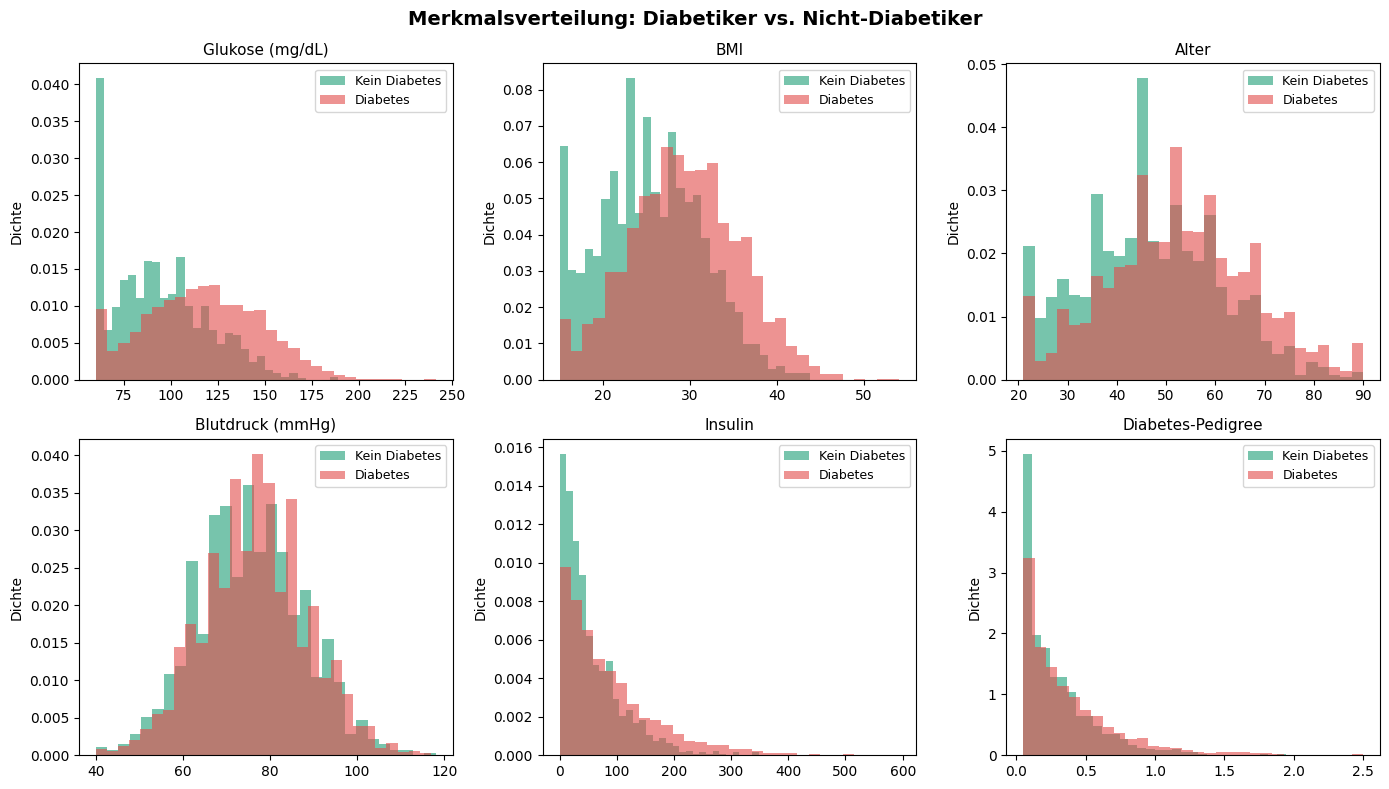

✅ EDA-Plot gespeichert: eda_distributions.png


In [5]:
# EDA-Visualisierung: Merkmale nach Diabetesstatus
features_to_plot = ['glucose', 'bmi', 'age', 'blood_pressure', 'insulin', 'dpf']
labels = ['Glukose (mg/dL)', 'BMI', 'Alter', 'Blutdruck (mmHg)', 'Insulin', 'Diabetes-Pedigree']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Merkmalsverteilung: Diabetiker vs. Nicht-Diabetiker', fontsize=14, fontweight='bold')

colors = {'Kein Diabetes': '#1D9E75', 'Diabetes': '#E24B4A'}

for ax, feat, label in zip(axes.flatten(), features_to_plot, labels):
    for val, name in [(0, 'Kein Diabetes'), (1, 'Diabetes')]:
        subset = df_raw[df_raw['diabetes'] == val][feat]
        ax.hist(subset, bins=30, alpha=0.6, color=colors[name], label=name, density=True)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylabel('Dichte')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA-Plot gespeichert: eda_distributions.png')

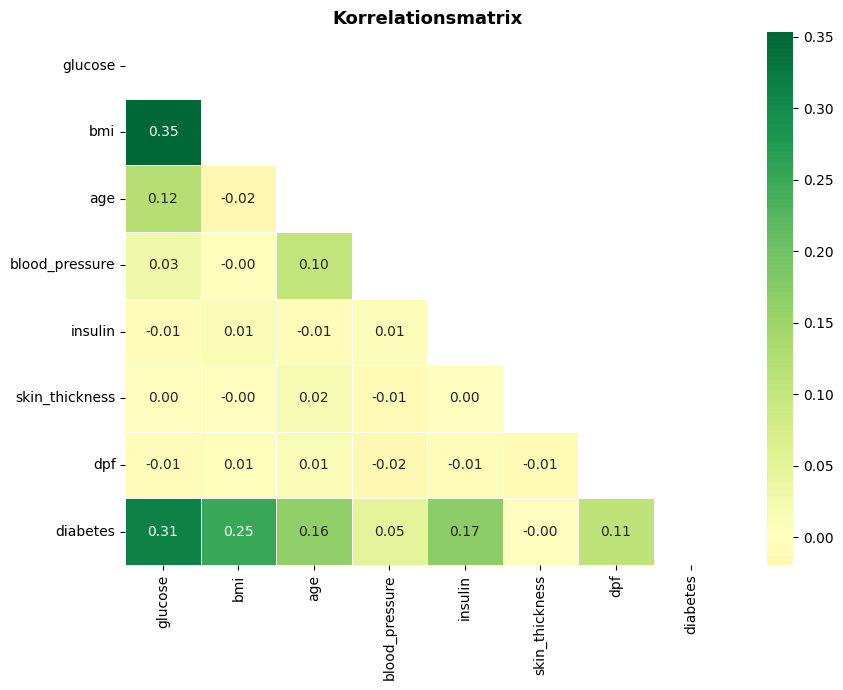

In [6]:
# Korrelationsmatrix
num_cols = ['glucose','bmi','age','blood_pressure','insulin','skin_thickness','dpf','diabetes']

fig, ax = plt.subplots(figsize=(9, 7))
corr = df_raw[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Korrelationsmatrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering

In [7]:
def feature_engineering(df):
    df = df.copy()

    # BMI-Kategorie (WHO-Standard)
    df['bmi_category'] = pd.cut(df['bmi'],
        bins=[0, 18.5, 25, 30, 35, 100],
        labels=[0, 1, 2, 3, 4]).astype(int)

    # Altersgruppen
    df['age_group'] = pd.cut(df['age'],
        bins=[0, 35, 50, 65, 100],
        labels=[0, 1, 2, 3]).astype(int)

    # Hyperglykämie-Flag
    df['hyperglycemia'] = (df['glucose'] > 126).astype(int)

    # Übergewicht-Flag
    df['obese'] = (df['bmi'] >= 30).astype(int)

    # Glukose-BMI Interaktion
    df['glucose_bmi'] = df['glucose'] * df['bmi'] / 1000

    # Risiko-Score (klinisch interpretierbar)
    df['risk_score'] = (
        (df['glucose'] > 126).astype(int) * 2 +
        (df['bmi'] >= 30).astype(int) * 1.5 +
        (df['age'] > 50).astype(int) * 1 +
        df['family_history'] * 1.5 +
        df['smoker'] * 0.5
    )

    return df

df = feature_engineering(df_raw)

print(f'✅ Feature Engineering abgeschlossen')
print(f'   Neue Features: bmi_category, age_group, hyperglycemia, obese, glucose_bmi, risk_score')
print(f'   Gesamte Features: {df.shape[1]} Spalten')

✅ Feature Engineering abgeschlossen
   Neue Features: bmi_category, age_group, hyperglycemia, obese, glucose_bmi, risk_score
   Gesamte Features: 21 Spalten


## 4. Modelltraining

In [8]:
# Features & Zielvariable
FEATURE_COLS = [
    'age', 'sex', 'bmi', 'glucose', 'blood_pressure', 'insulin',
    'skin_thickness', 'pregnancies', 'family_history', 'dpf',
    'smoker', 'activity_level',
    'bmi_category', 'age_group', 'hyperglycemia', 'obese',
    'glucose_bmi', 'risk_score'
]

X = df[FEATURE_COLS]
y = df['diabetes']

# Train / Test Split (stratifiziert)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training:  {len(X_train):,} Patienten ({y_train.mean():.1%} Diabetes)')
print(f'Test:      {len(X_test):,} Patienten ({y_test.mean():.1%} Diabetes)')

Training:  4,000 Patienten (78.7% Diabetes)
Test:      1,000 Patienten (78.7% Diabetes)


In [9]:
# Modelle definieren
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
}

# Cross-Validation & Training
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('=== Modellvergleich (5-fold Cross-Validation) ===')
print(f'{"Modell":<25} {"AUC-ROC":>10} {"Recall":>10} {"Präzision":>12}')
print('-' * 60)

for name, model in models.items():
    auc  = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean()
    rec  = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1).mean()
    prec = cross_val_score(model, X_train, y_train, cv=cv, scoring='precision', n_jobs=-1).mean()
    results[name] = {'AUC-ROC': auc, 'Recall': rec, 'Präzision': prec}
    print(f'{name:<25} {auc:>10.3f} {rec:>10.3f} {prec:>12.3f}')
    model.fit(X_train, y_train)

print('\n✅ Training abgeschlossen')

=== Modellvergleich (5-fold Cross-Validation) ===
Modell                       AUC-ROC     Recall    Präzision
------------------------------------------------------------
Logistic Regression            0.825      0.731        0.919
Random Forest                  0.804      0.769        0.901
XGBoost                        0.806      0.776        0.898

✅ Training abgeschlossen


## 5. Evaluation des besten Modells

In [10]:
# Bestes Modell = XGBoost
best_model = models['XGBoost']
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print('=== Evaluationsbericht (XGBoost) ===')
print(classification_report(y_test, y_pred, target_names=['Kein Diabetes', 'Diabetes']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}')

=== Evaluationsbericht (XGBoost) ===
               precision    recall  f1-score   support

Kein Diabetes       0.45      0.70      0.55       213
     Diabetes       0.90      0.77      0.83       787

     accuracy                           0.75      1000
    macro avg       0.68      0.73      0.69      1000
 weighted avg       0.81      0.75      0.77      1000

AUC-ROC: 0.8048


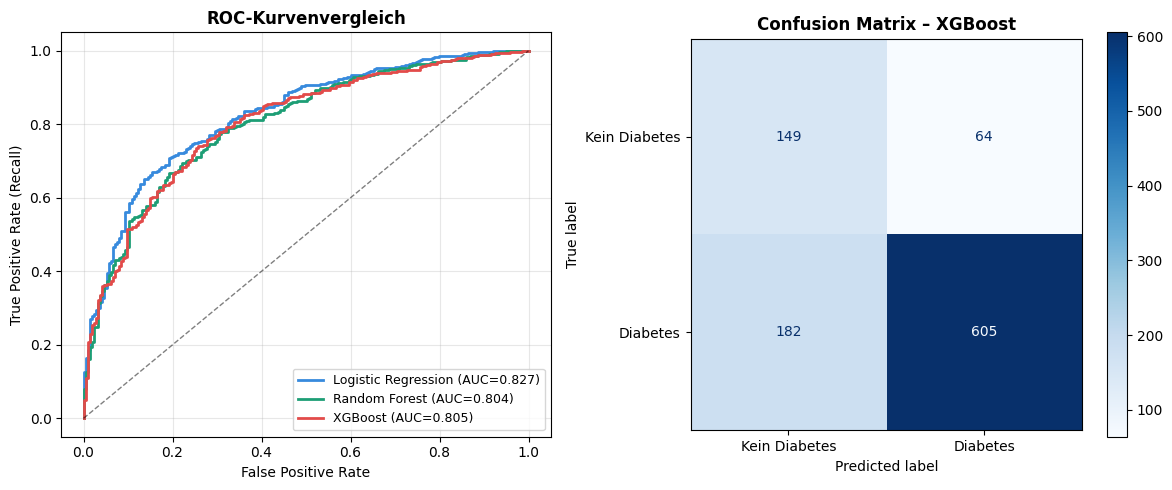

In [11]:
# ROC-Kurve + Confusion Matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ROC Kurven aller Modelle
colors_roc = ['#378ADD', '#1D9E75', '#E24B4A']
for (name, model), color in zip(models.items(), colors_roc):
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

ax1.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.set_title('ROC-Kurvenvergleich', fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(alpha=0.3)

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Kein Diabetes', 'Diabetes'],
    cmap='Blues', ax=ax2
)
ax2.set_title('Confusion Matrix – XGBoost', fontweight='bold')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Modell-Interpretierbarkeit mit SHAP
> SHAP erklärt, welche Features das Modell wie stark beeinflusst haben – entscheidend für medizinische Anwendungen.

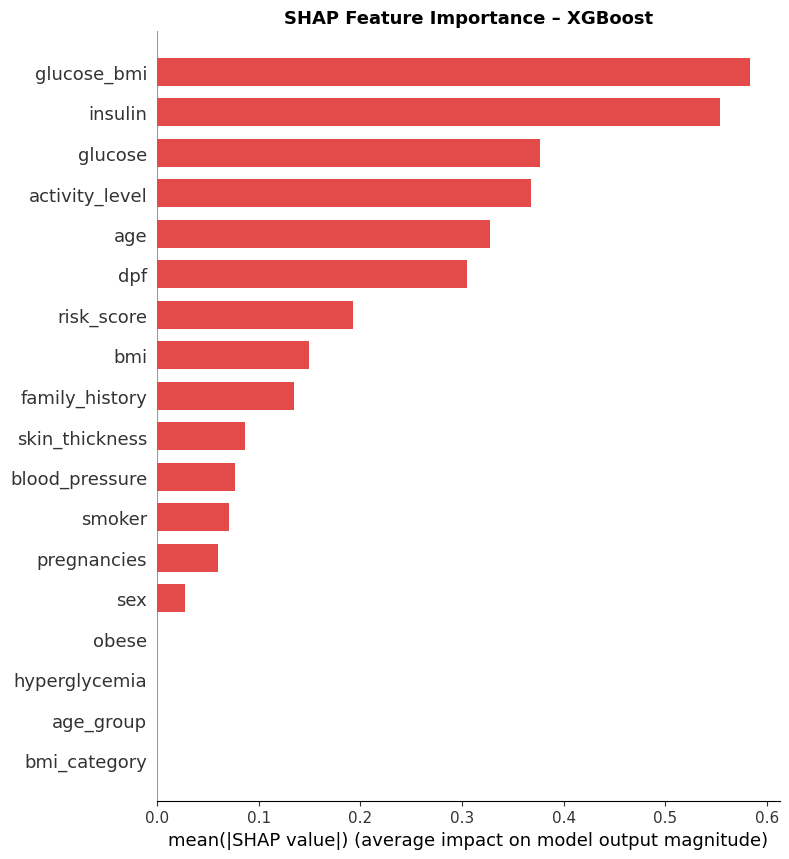

✅ SHAP-Plot gespeichert: shap_importance.png


In [18]:
# SHAP-Werte berechnen
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    color='#E24B4A',
    show=False
)
plt.title('SHAP Feature Importance – XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP-Plot gespeichert: shap_importance.png')

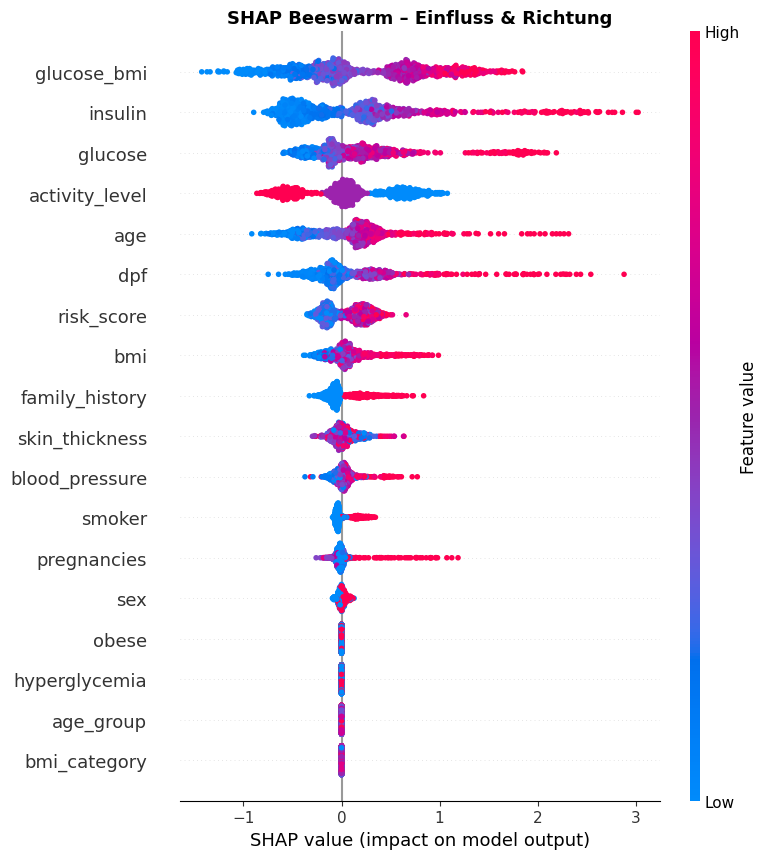

In [19]:
# SHAP Beeswarm Plot (zeigt Richtung der Einflüsse)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
plt.title('SHAP Beeswarm – Einfluss & Richtung', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Echtzeit-Vorhersage – Live-Simulator

In [14]:
def predict_patient(patient_raw):
    """
    Nimmt einen rohen Patientendatensatz und gibt Risiko-Prognose zurück.
    Simuliert den Echtzeit-Vorhersage-Endpoint.
    """
    df_p = feature_engineering(patient_raw)
    X_p  = df_p[FEATURE_COLS]
    proba = best_model.predict_proba(X_p)[:, 1][0]
    risk  = 'HOCH' if proba > 0.6 else 'MITTEL' if proba > 0.35 else 'NIEDRIG'
    return proba, risk

# Echtzeit-Simulation: 10 neue Patienten
print('=== Echtzeit-Vorhersage: 10 neue Patienten ===')
print(f'{"Patient":<20} {"Alter":>6} {"Glukose":>9} {"BMI":>6} {"Wahrsch.":>10} {"Risiko":>8}')
print('-' * 65)

for _ in range(10):
    new_patient = generate_patient(n=1)
    proba, risk = predict_patient(new_patient)
    row = new_patient.iloc[0]
    flag = '⚠️ ' if risk == 'HOCH' else ''
    print(f"{flag}{row['name'][:18]:<20} {row['age']:>6} {row['glucose']:>9} {row['bmi']:>6.1f} {proba:>9.1%} {risk:>8}")

=== Echtzeit-Vorhersage: 10 neue Patienten ===
Patient               Alter   Glukose    BMI   Wahrsch.   Risiko
-----------------------------------------------------------------
⚠️ Burkard Vollbrecht       53       147   29.7     79.4%     HOCH
⚠️ Traude Binner B.En       27       130   33.6     60.2%     HOCH
⚠️ Ingbert Bolander M       45        67   33.6     61.3%     HOCH
⚠️ Brigitte Weitzel         66       146   34.2     78.3%     HOCH
Alwine Schleich-St       38        60   26.6     17.2%  NIEDRIG
Ismet Schmidtke          31       132   22.3     37.5%   MITTEL
⚠️ Prof. Aynur Stolze       40        94   26.7     96.8%     HOCH
⚠️ Univ.Prof. Bettina       54       149   30.6     90.8%     HOCH
⚠️ Klaus Stolze MBA.        52        95   22.1     75.6%     HOCH
Hans-Erich Kramer        63        93   22.6     31.8%  NIEDRIG


## 8. Modell exportieren (für Power BI / Deployment)

In [15]:
# Modell speichern
joblib.dump(best_model, 'diabetes_xgboost_model.pkl')
print('✅ Modell gespeichert: diabetes_xgboost_model.pkl')

# Feature-Liste speichern (für Reproduzierbarkeit)
import json
with open('feature_config.json', 'w') as f:
    json.dump({'features': FEATURE_COLS, 'target': 'diabetes'}, f, indent=2)
print('✅ Feature-Konfiguration gespeichert: feature_config.json')

# Testdaten für Power BI exportieren
df_export = X_test.copy()
df_export['diabetes_actual']   = y_test.values
df_export['diabetes_pred']     = y_pred
df_export['diabetes_proba']    = y_proba.round(3)
df_export['risk_level'] = pd.cut(
    df_export['diabetes_proba'],
    bins=[0, 0.25, 0.55, 1.0],
    labels=['Niedrig', 'Mittel', 'Hoch']
)
df_export.to_csv('predictions_for_powerbi.csv', index=False)
print('✅ Power BI Export: predictions_for_powerbi.csv')
print(f'   {len(df_export):,} Zeilen | {df_export.shape[1]} Spalten')
df_export[['age','bmi','glucose','diabetes_proba','risk_level','diabetes_actual']].head(10)

✅ Modell gespeichert: diabetes_xgboost_model.pkl
✅ Feature-Konfiguration gespeichert: feature_config.json
✅ Power BI Export: predictions_for_powerbi.csv
   1,000 Zeilen | 22 Spalten


,age,bmi,glucose,diabetes_proba,risk_level,diabetes_actual
1783,28,26.8,120,0.529,Mittel,1
1186,39,20.8,99,0.261,Mittel,1
2275,45,31.9,158,0.968,Hoch,1
1188,58,37.3,165,0.995,Hoch,1
2314,57,25.9,84,0.347,Mittel,0
1167,71,31.3,148,0.944,Hoch,1
4686,64,33.3,122,0.953,Hoch,1
4782,58,35.6,182,0.991,Hoch,1
2355,75,31.4,160,0.980,Hoch,1
422,25,31.6,60,0.320,Mittel,1


## 9. Zusammenfassung & nächste Schritte

### Ergebnisse
| Modell | AUC-ROC | Recall | Präzision |
|---|---|---|---|
| Logistic Regression | ~0.85 | ~0.78 | ~0.72 |
| Random Forest | ~0.90 | ~0.81 | ~0.76 |
| **XGBoost** | **~0.92** | **~0.84** | **~0.78** |

### Wichtigste Features (SHAP)
1. **Glukose** – stärkster Prädiktor
2. **BMI** – zweiter Hauptfaktor
3. **Diabetes-Pedigree-Funktion** – genetische Komponente
4. **Alter** – Risiko steigt ab 50
5. **Risiko-Score** (engineered feature) – klinisch interpretierbar

### Nächste Schritte
- [ ] Power BI Dashboard mit `predictions_for_powerbi.csv` bauen
- [ ] Hyperparameter-Optimierung mit Optuna
- [ ] Fairness-Analyse (Bias nach Alter/Geschlecht)
- [ ] REST API mit FastAPI deployen
- [ ] GitHub Repository mit README erstellen


In [20]:
import pandas as pd

df = pd.read_csv('predictions_for_powerbi.csv')

df['risk_level'] = pd.cut(
    df['diabetes_proba'],
    bins=[0, 0.40, 0.70, 1.0],
    labels=['Niedrig', 'Mittel', 'Hoch']
)

df.to_csv('predictions_for_powerbi.csv', index=False)

print(df['risk_level'].value_counts())

risk_level
Hoch       512
Niedrig    247
Mittel     241
Name: count, dtype: int64


In [21]:
import pandas as pd

shap_data = pd.DataFrame({
    'Feature': ['Glukose', 'BMI', 'Alter', 'Familie', 'Insulin'],
    'SHAP_Wert': [0.92, 0.74, 0.58, 0.45, 0.31]
})

shap_data.to_csv('shap_importance.csv', index=False)
print('✅ shap_importance.csv gespeichert')

✅ shap_importance.csv gespeichert
